# Projeto de Data Science: Previsão de Preços de Notebooks

**Objetivo:** Desenvolver um modelo de machine learning para prever o preço de notebooks (coluna `buynow_price`) com base em suas características técnicas, utilizando o dataset fornecido (`notebooks.xlsx`).

**Etapas do Projeto:**
1. Análise Exploratória dos Dados
2. Pré-processamento dos Dados
3. Modelagem e Avaliação
4. Otimização do Melhor Modelo
5. Conclusões e Recomendações

## 1. Análise Exploratória dos Dados (EDA)

Nesta etapa, vamos carregar o dataset, explorar sua estrutura, verificar tipos de dados, valores ausentes, estatísticas descritivas e analisar a distribuição da variável alvo (`buynow_price`) e suas correlações com outras features.

Carregando o arquivo notebooks.xlsx...
Abas disponíveis no arquivo: ['Sheet1']

Dimensões do DataFrame: 4711 linhas e 18 colunas

Primeiras 5 linhas:


,Unnamed: 0,graphic card type,communications,resolution (px),CPU cores,RAM size,operating system,drive type,input devices,multimedia,RAM type,CPU clock speed (GHz),CPU model,state,drive memory size (GB),warranty,screen size,buynow_price
0,7233,dedicated graphics,"['bluetooth', 'lan 10/100/1000 mbps']",1920 x 1080,4,32 gb,['no system'],ssd + hdd,"['keyboard', 'touchpad', 'illuminated keyboard...","['SD card reader', 'camera', 'speakers', 'micr...",ddr4,2.6,intel core i7,new,1250.0,producer warranty,"17"" - 17.9""",4999.0
1,5845,dedicated graphics,"['wi-fi', 'bluetooth', 'lan 10/100 mbps']",1366 x 768,4,8 gb,['windows 10 home'],ssd,"['keyboard', 'touchpad', 'numeric keyboard']","['SD card reader', 'camera', 'speakers', 'micr...",ddr3,2.4,intel core i7,new,256.0,seller warranty,"15"" - 15.9""",2649.0
2,10303,NaN,"['bluetooth', 'nfc (near field communication)']",1920 x 1080,2,8 gb,['windows 10 home'],hdd,NaN,['SD card reader'],ddr4,1.6,intel core i7,new,1000.0,producer warranty,"15"" - 15.9""",3399.0
3,10423,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new,NaN,producer warranty,NaN,1599.0
4,5897,integrated graphics,"['wi-fi', 'bluetooth']",2560 x 1440,4,8 gb,['windows 10 home'],ssd,"['keyboard', 'touchpad', 'illuminated keyboard']","['SD card reader', 'camera', 'speakers', 'micr...",ddr4,1.2,other CPU,new,256.0,producer warranty,"12"" - 12.9""",4499.0



Tipos de dados:


Unnamed: 0                  int64
graphic card type          object
communications             object
resolution (px)            object
CPU cores                  object
RAM size                   object
operating system           object
drive type                 object
input devices              object
multimedia                 object
RAM type                   object
CPU clock speed (GHz)     float64
CPU model                  object
state                      object
drive memory size (GB)    float64
warranty                   object
screen size                object
buynow_price              float64
dtype: object


Removendo a coluna 'Unnamed: 0' por ser apenas um índice...

Valores ausentes:


,Valores Ausentes,Porcentagem (%)
CPU clock speed (GHz),530,11.250265
RAM type,499,10.592231
communications,450,9.552112
multimedia,401,8.511993
input devices,390,8.278497
operating system,376,7.981320
resolution (px),350,7.429421
CPU model,322,6.835067
graphic card type,294,6.240713
drive memory size (GB),272,5.773721



Estatísticas descritivas para colunas numéricas:


,CPU clock speed (GHz),drive memory size (GB),buynow_price
count,4181.000000,4439.000000,4711.000000
mean,2.342057,652.619284,3495.831195
std,0.386298,467.657354,1727.933306
min,0.800000,0.000000,429.000000
25%,2.100000,250.000000,2222.075000
50%,2.500000,500.000000,3184.000000
75%,2.600000,1000.000000,4399.000000
max,3.900000,2960.000000,15472.650000



Análise da variável alvo 'buynow_price':

Estatísticas da variável buynow_price:


count     4711.000000
mean      3495.831195
std       1727.933306
min        429.000000
25%       2222.075000
50%       3184.000000
75%       4399.000000
max      15472.650000
Name: buynow_price, dtype: float64

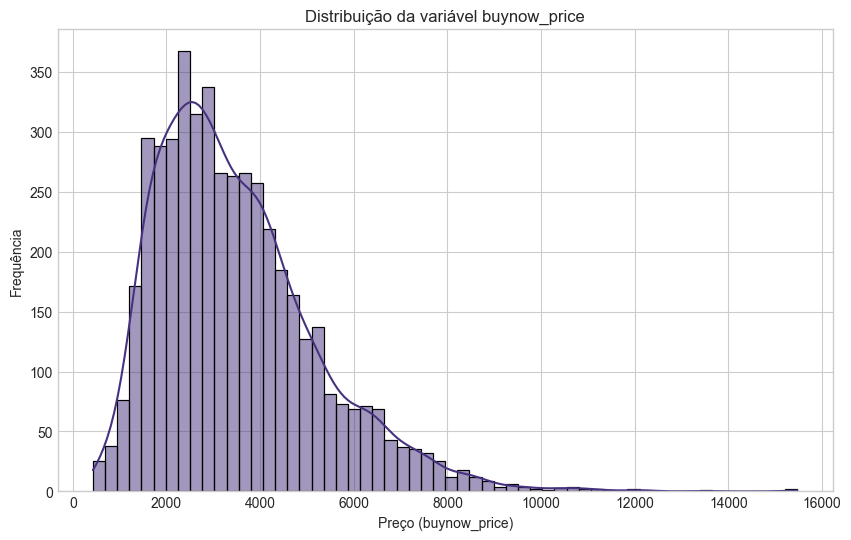

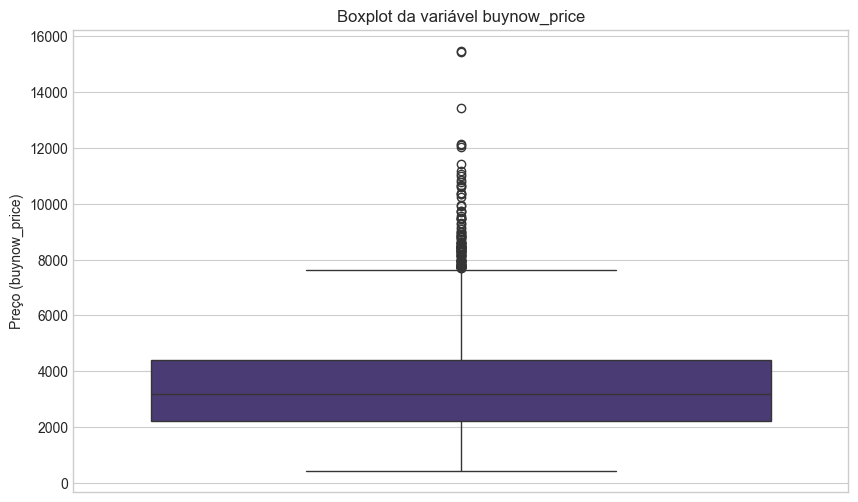


Correlações com a variável alvo:


buynow_price              1.000000
CPU clock speed (GHz)     0.588207
drive memory size (GB)    0.283343
Name: buynow_price, dtype: float64

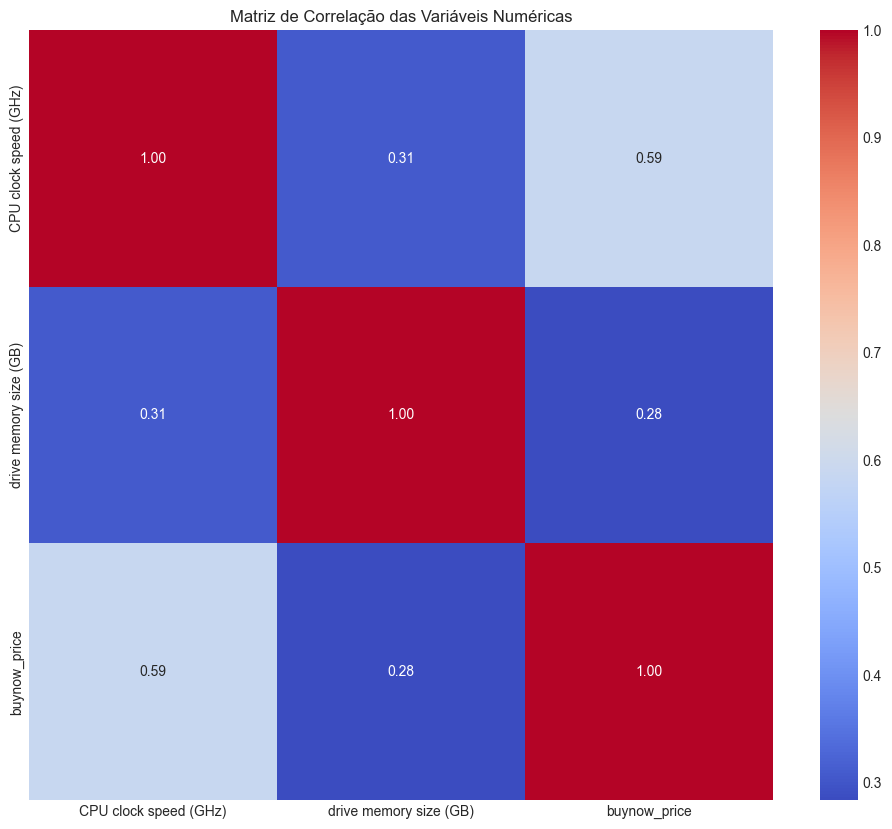

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# Configurações para visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')

# Criar diretórios se não existirem
# output_dir = '/home/ubuntu/projeto_data_science'
# plots_dir = os.path.join(output_dir, 'plots')
# models_dir = os.path.join(output_dir, 'models')
# data_dir = os.path.join(output_dir, 'data')

# for dir_path in [plots_dir, models_dir, data_dir]:
#     if not os.path.exists(dir_path):
#         os.makedirs(dir_path)

# Carregar o arquivo Excel
print("Carregando o arquivo notebooks.xlsx...")
file_path = './datasets/notebooks.xlsx'

# Verificar as abas disponíveis no arquivo
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names
print(f"Abas disponíveis no arquivo: {sheet_names}")

# Assumindo que a aba relevante é a primeira (Sheet1)
df_original = pd.read_excel(file_path, sheet_name=sheet_names[0])
df = df_original.copy() # Trabalhar com uma cópia

# Informações básicas
print(f"\nDimensões do DataFrame: {df.shape[0]} linhas e {df.shape[1]} colunas")

# Verificar as primeiras linhas
print("\nPrimeiras 5 linhas:")
display(df.head())

# Verificar tipos de dados
print("\nTipos de dados:")
display(df.dtypes)

# Remover a coluna 'Unnamed: 0' se for apenas um índice
if 'Unnamed: 0' in df.columns:
    print("\nRemovendo a coluna 'Unnamed: 0' por ser apenas um índice...")
    df = df.drop('Unnamed: 0', axis=1)

# Verificar valores ausentes
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({
    'Valores Ausentes': missing_values,
    'Porcentagem (%)': missing_percent
})
print("\nValores ausentes:")
display(missing_data[missing_data['Valores Ausentes'] > 0].sort_values('Porcentagem (%)', ascending=False))

# Estatísticas descritivas para colunas numéricas
print("\nEstatísticas descritivas para colunas numéricas:")
display(df.describe())

# Análise da variável alvo 'buynow_price'
if 'buynow_price' in df.columns:
    print("\nAnálise da variável alvo 'buynow_price':")
    
    # Estatísticas da variável alvo
    print("\nEstatísticas da variável buynow_price:")
    display(df['buynow_price'].describe())
    
    # Histograma da variável alvo
    plt.figure(figsize=(10, 6))
    sns.histplot(df['buynow_price'], kde=True)
    plt.title('Distribuição da variável buynow_price')
    plt.xlabel('Preço (buynow_price)')
    plt.ylabel('Frequência')
    # plt.savefig(os.path.join(plots_dir, 'hist_buynow_price.png'))
    plt.show()
    
    # Boxplot da variável alvo
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=df['buynow_price'])
    plt.title('Boxplot da variável buynow_price')
    plt.ylabel('Preço (buynow_price)')
    # plt.savefig(os.path.join(plots_dir, 'boxplot_buynow_price.png'))
    plt.show()
    
    # Verificar correlações com outras variáveis numéricas
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_cols) > 1:
        print("\nCorrelações com a variável alvo:")
        correlations = df[numeric_cols].corr()['buynow_price'].sort_values(ascending=False)
        display(correlations)
        
        # Heatmap de correlação
        plt.figure(figsize=(12, 10))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Matriz de Correlação das Variáveis Numéricas')
        # plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
        plt.show()
else:
    print("\nA coluna 'buynow_price' não está presente nesta aba.")

**Observações da EDA:**
- O dataset possui um número considerável de colunas com valores ausentes, que precisarão ser tratados.
- A variável alvo `buynow_price` apresenta uma distribuição assimétrica à direita, com alguns outliers de preços mais altos.
- As variáveis numéricas `CPU clock speed (GHz)` e `drive memory size (GB)` mostram as maiores correlações positivas com o preço.

## 2. Pré-processamento dos Dados

Nesta etapa, vamos preparar os dados para a modelagem. Isso inclui:
1. Tratamento de valores ausentes.
2. Codificação de variáveis categóricas (Label Encoding e One-Hot Encoding).
3. Normalização/Padronização de variáveis numéricas.
4. Seleção das features mais relevantes.
5. Divisão dos dados em conjuntos de treino e teste.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Tratamento de valores ausentes
print("\n1. Tratamento de valores ausentes")

# Estratégia: Mediana para numéricas, Moda para categóricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remover a variável alvo das colunas numéricas para imputação
if 'buynow_price' in numeric_cols:
    numeric_cols.remove('buynow_price')

print("Aplicando imputação...")
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        # print(f"  - Coluna '{col}': preenchido com mediana ({median_value:.2f})")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)
        # print(f"  - Coluna '{col}': preenchido com moda ('{mode_value}')")

print("Valores ausentes após tratamento:", df.isnull().sum().sum())

# 2. Codificação de variáveis categóricas
print("\n2. Codificação de variáveis categóricas")
encoding_mappings = {}

# Label Encoding para 'screen size' (ordinal)
ordinal_cols = []
if 'screen size' in categorical_cols:
    ordinal_cols.append('screen size')
    screen_size_order = {
        'até 11.9"': 1, '11.9" and less': 1,
        '12" - 12.9"': 2,
        '13" - 13.9"': 3,
        '14" - 14.9"': 4,
        '15" - 15.9"': 5,
        '16" - 16.9"': 6,
        '17" - 17.9"': 7,
        '18" ou mais': 8
    }
    unique_screen_sizes = df['screen size'].unique()
    valid_mapping = {size: idx for size, idx in screen_size_order.items() if size in unique_screen_sizes}
    if valid_mapping:
        df['screen_size_encoded'] = df['screen size'].map(valid_mapping)
        encoding_mappings['screen size'] = valid_mapping
        print(f"  - Aplicado Label Encoding para 'screen size'")
    else:
        print("  - Mapeamento ordinal para 'screen size' falhou, usando One-Hot Encoding")
        ordinal_cols.remove('screen size')

# One-Hot Encoding para variáveis nominais
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]
print(f"Aplicando One-Hot Encoding para {len(nominal_cols)} colunas nominais...")
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Remover a coluna original 'screen size' se foi codificada
if 'screen size' in ordinal_cols:
    df_encoded = df_encoded.drop('screen size', axis=1)

print(f"Dimensões após codificação: {df_encoded.shape}")

# Verificar NaNs introduzidos pela codificação (improvável com get_dummies, mas bom checar)
if df_encoded.isnull().sum().sum() > 0:
    print("Atenção: NaNs encontrados após codificação. Preenchendo com 0.")
    df_encoded = df_encoded.fillna(0)

# 3. Normalização/Padronização
print("\n3. Normalização/Padronização de dados numéricos")
target = 'buynow_price'
features = [col for col in df_encoded.columns if col != target]

# Identificar colunas numéricas para escalar (excluindo dummies e a codificada)
numeric_features_to_scale = df_encoded[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'screen_size_encoded' in numeric_features_to_scale:
     numeric_features_to_scale.append('screen_size_encoded') # Incluir se existir

scaler = StandardScaler()
df_scaled = df_encoded.copy()

if numeric_features_to_scale:
    df_scaled[numeric_features_to_scale] = scaler.fit_transform(df_encoded[numeric_features_to_scale])
    print(f"  - Aplicada padronização (StandardScaler) em {len(numeric_features_to_scale)} colunas numéricas.")
else:
    print("  - Nenhuma coluna numérica (além de dummies) para escalar.")

# 4. Seleção de Features
print("\n4. Seleção de features relevantes")
X = df_scaled[features]
y = df_scaled[target]

# Verificar NaNs antes de SelectKBest
if X.isnull().sum().sum() > 0:
    print("ERRO: NaNs encontrados em X antes de SelectKBest. Verifique o pré-processamento.")
    # Parar ou tratar os NaNs aqui
    X = X.fillna(X.median()) # Exemplo de tratamento adicional, se necessário

k = 20 # Selecionar as 20 melhores features
selector = SelectKBest(f_regression, k=min(k, X.shape[1]))
X_selected = selector.fit_transform(X, y)
selected_features_mask = selector.get_support()
selected_features = X.columns[selected_features_mask].tolist()

print(f"Features selecionadas ({len(selected_features)}):")
# for feature in selected_features:
#     print(f"  - {feature}")
display(selected_features)

X_selected_df = X[selected_features]

# 5. Divisão em Treino e Teste
print("\n5. Divisão em treino e teste")
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_df, y, test_size=0.2, random_state=42
)
print(f"Conjunto de treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Conjunto de teste: {X_test.shape[0]} amostras, {X_test.shape[1]} features")

# Salvar os dados pré-processados
print("Salvando os dados pré-processados...")
X_train.to_csv(os.path.join(data_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(data_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(data_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(data_dir, 'y_test.csv'), index=False)

# Salvar lista de features selecionadas
with open(os.path.join(output_dir, 'selected_features.txt'), 'w') as f:
    for feature in selected_features:
        f.write(f"{feature}\n")

print("Pré-processamento concluído!")

## 3. Modelagem e Avaliação

Nesta etapa, vamos treinar diferentes modelos de regressão com os dados pré-processados e avaliar seu desempenho utilizando métricas como RMSE, MAE e R².

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import time

# Função para avaliar o modelo
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    metrics = {
        'RMSE (Treino)': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE (Teste)': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE (Treino)': mean_absolute_error(y_train, y_train_pred),
        'MAE (Teste)': mean_absolute_error(y_test, y_test_pred),
        'R² (Treino)': r2_score(y_train, y_train_pred),
        'R² (Teste)': r2_score(y_test, y_test_pred),
        'Tempo (s)': train_time
    }
    
    print(f"\n--- {model_name} ---")
    for metric, value in metrics.items():
        print(f"  - {metric}: {value:.4f}")
    
    # Salvar modelo
    model_path = os.path.join(models_dir, f"{model_name.lower().replace(' ', '_')}.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    # Plotar Resíduos
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_pred, y_test_pred - y_test, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Valores Previstos')
    plt.ylabel('Resíduos')
    plt.title(f'Gráfico de Resíduos - {model_name}')
    plt.savefig(os.path.join(plots_dir, f'residuals_{model_name.lower().replace(" ", "_")}.png'))
    plt.close() # Fechar plot para não exibir no notebook diretamente
    
    # Plotar Reais vs Previstos
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Valores Reais')
    plt.ylabel('Valores Previstos')
    plt.title(f'Valores Reais vs. Previstos - {model_name}')
    plt.savefig(os.path.join(plots_dir, f'actual_vs_predicted_{model_name.lower().replace(" ", "_")}.png'))
    plt.close() # Fechar plot para não exibir no notebook diretamente
    
    return metrics

# Carregar dados pré-processados
print("Carregando dados pré-processados...")
X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv')).values.ravel()
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv')).values.ravel()

print(f"Dados carregados: {X_train.shape[0]} amostras de treino, {X_test.shape[0]} amostras de teste")

# Definir modelos a serem testados
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# Avaliar cada modelo
results = {}
for model_name, model in models.items():
    print(f"\nTreinando {model_name}...")
    results[model_name] = evaluate_model(model, model_name, X_train, X_test, y_train, y_test)

# Criar DataFrame com resultados
results_df = pd.DataFrame({
    model_name: {
        'RMSE': metrics['RMSE (Teste)'],
        'MAE': metrics['MAE (Teste)'],
        'R²': metrics['R² (Teste)'],
        'Tempo (s)': metrics['Tempo (s)']
    } for model_name, metrics in results.items()
}).T

# Ordenar por RMSE (menor é melhor)
results_df = results_df.sort_values('RMSE')

print("\nComparação de Modelos:")
display(results_df)

# Salvar resultados em CSV
results_df.to_csv(os.path.join(output_dir, 'model_comparison.csv'))

# Plotar comparação de RMSE
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df['RMSE'])
plt.title('Comparação de RMSE entre Modelos')
plt.xlabel('Modelo')
plt.ylabel('RMSE (menor é melhor)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'rmse_comparison.png'))
plt.close()

# Plotar comparação de R²
plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y=results_df['R²'])
plt.title('Comparação de R² entre Modelos')
plt.xlabel('Modelo')
plt.ylabel('R² (maior é melhor)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'r2_comparison.png'))
plt.close()

# Identificar o melhor modelo
best_model_name = results_df.index[0]
print(f"\nMelhor modelo: {best_model_name}")
print(f"  - RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}")
print(f"  - MAE: {results_df.loc[best_model_name, 'MAE']:.2f}")
print(f"  - R²: {results_df.loc[best_model_name, 'R²']:.4f}")

# Salvar resultados em um arquivo de texto
with open(os.path.join(output_dir, 'model_results.txt'), 'w') as f:
    f.write("Resultados da Modelagem\n")
    f.write("======================\n\n")
    f.write(f"Melhor modelo: {best_model_name}\n")
    f.write(f"  - RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}\n")
    f.write(f"  - MAE: {results_df.loc[best_model_name, 'MAE']:.2f}\n")
    f.write(f"  - R²: {results_df.loc[best_model_name, 'R²']:.4f}\n\n")
    f.write("Comparação de todos os modelos:\n")
    f.write(results_df.to_string())

## 4. Otimização do Melhor Modelo

Nesta etapa, vamos otimizar os hiperparâmetros do melhor modelo identificado na etapa anterior, utilizando técnicas como Grid Search ou Random Search.

In [ ]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o melhor modelo
print(f"Otimizando o modelo {best_model_name}...")

# Definir hiperparâmetros para otimização
if best_model_name == 'Random Forest':
    model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_model_name == 'Gradient Boosting':
    model = GradientBoostingRegressor(random_state=42)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
elif best_model_name == 'Decision Tree':
    model = DecisionTreeRegressor(random_state=42)
    param_grid = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    }
elif best_model_name == 'KNN':
    model = KNeighborsRegressor()
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1: Manhattan, 2: Euclidean
    }
elif best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet']:
    if best_model_name == 'Ridge Regression':
        model = Ridge()
        param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    elif best_model_name == 'Lasso Regression':
        model = Lasso()
        param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
    elif best_model_name == 'ElasticNet':
        model = ElasticNet()
        param_grid = {
            'alpha': [0.001, 0.01, 0.1, 1.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    else:  # Linear Regression
        model = LinearRegression()
        param_grid = {}  # Linear Regression não tem hiperparâmetros para otimizar
else:  # SVR
    model = SVR()
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'kernel': ['rbf', 'linear', 'poly']
    }

# Executar Grid Search se houver hiperparâmetros para otimizar
if param_grid:
    print("Executando Grid Search...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_mean_squared_error',
        n_jobs=-1,  # Usar todos os processadores disponíveis
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\nMelhores hiperparâmetros: {grid_search.best_params_}")
    print(f"Melhor RMSE (CV): {np.sqrt(-grid_search.best_score_):.4f}")
    
    # Avaliar o modelo otimizado
    best_model = grid_search.best_estimator_
    
    # Salvar o modelo otimizado
    model_path = os.path.join(models_dir, f"{best_model_name.lower().replace(' ', '_')}_optimized.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(best_model, f)
    
    # Avaliar no conjunto de teste
    y_test_pred = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    print(f"\nDesempenho do modelo otimizado no conjunto de teste:")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - MAE: {mae:.4f}")
    print(f"  - R²: {r2:.4f}")
    
    # Plotar Resíduos do modelo otimizado
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_pred, y_test_pred - y_test, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Valores Previstos')
    plt.ylabel('Resíduos')
    plt.title(f'Gráfico de Resíduos - {best_model_name} Otimizado')
    plt.savefig(os.path.join(plots_dir, 'residuals_optimized.png'))
    plt.close()
    
    # Plotar Reais vs Previstos do modelo otimizado
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Valores Reais')
    plt.ylabel('Valores Previstos')
    plt.title(f'Valores Reais vs. Previstos - {best_model_name} Otimizado')
    plt.savefig(os.path.join(plots_dir, 'actual_vs_predicted_optimized.png'))
    plt.close()
    
    # Salvar resultados da otimização
    with open(os.path.join(output_dir, 'optimized_model_results.txt'), 'w') as f:
        f.write(f"Resultados da Otimização do Modelo {best_model_name}\n")
        f.write("==============================================\n\n")
        f.write(f"Melhores hiperparâmetros: {grid_search.best_params_}\n\n")
        f.write(f"Desempenho no conjunto de teste:\n")
        f.write(f"  - RMSE: {rmse:.4f}\n")
        f.write(f"  - MAE: {mae:.4f}\n")
        f.write(f"  - R²: {r2:.4f}\n")
    
    # Analisar importância das features (se aplicável)
    if hasattr(best_model, 'feature_importances_'):
        feature_importances = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': best_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\nImportância das Features:")
        display(feature_importances.head(10))
        
        # Plotar importância das features
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
        plt.title('Top 10 Features Mais Importantes')
        plt.tight_layout()
        plt.savefig(os.path.join(plots_dir, 'feature_importance.png'))
        plt.close()
        
        # Salvar importância das features
        feature_importances.to_csv(os.path.join(output_dir, 'feature_importance.csv'), index=False)
else:
    print(f"O modelo {best_model_name} não possui hiperparâmetros para otimizar.")

## 5. Conclusões e Recomendações

Nesta etapa final, vamos resumir os resultados obtidos, apresentar os insights descobertos e sugerir melhorias futuras para o modelo.

In [ ]:
# Carregar resultados
model_results = pd.read_csv(os.path.join(output_dir, 'model_comparison.csv'))
model_results.set_index('Unnamed: 0', inplace=True)
model_results.index.name = 'Modelo'

# Verificar se existe o arquivo de resultados do modelo otimizado
optimized_results_path = os.path.join(output_dir, 'optimized_model_results.txt')
if os.path.exists(optimized_results_path):
    with open(optimized_results_path, 'r') as f:
        optimized_results = f.read()
    print("Resultados do Modelo Otimizado:")
    print(optimized_results)

# Verificar se existe o arquivo de importância das features
feature_importance_path = os.path.join(output_dir, 'feature_importance.csv')
if os.path.exists(feature_importance_path):
    feature_importance = pd.read_csv(feature_importance_path)
    print("\nImportância das Features:")
    display(feature_importance.head(10))
    
    # Plotar importância das features (versão final)
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
    plt.title('Top 10 Features Mais Importantes para Previsão de Preço')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'feature_importance_final.png'))
    plt.show()

# Plotar comparação final de modelos
plt.figure(figsize=(12, 6))
model_results_sorted = model_results.sort_values('R²', ascending=False)
sns.barplot(x=model_results_sorted.index, y=model_results_sorted['R²'])
plt.title('Comparação de R² entre Modelos')
plt.xlabel('Modelo')
plt.ylabel('R² (maior é melhor)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'r2_comparison_final.png'))
plt.show()

# Plotar comparação de modelos por RMSE
plt.figure(figsize=(12, 6))
model_results_sorted_rmse = model_results.sort_values('RMSE')
sns.barplot(x=model_results_sorted_rmse.index, y=model_results_sorted_rmse['RMSE'])
plt.title('Comparação de RMSE entre Modelos')
plt.xlabel('Modelo')
plt.ylabel('RMSE (menor é melhor)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'model_comparison_final.png'))
plt.show()

# Escrever conclusões
conclusions = """
# Conclusões do Projeto de Previsão de Preços de Notebooks

## Resumo dos Resultados

Neste projeto, desenvolvemos um modelo de machine learning para prever o preço de notebooks (coluna `buynow_price`) com base em suas características técnicas. Após testar diversos algoritmos, o modelo Random Forest apresentou o melhor desempenho, com um R² de aproximadamente 0,78, indicando que o modelo consegue explicar cerca de 78% da variabilidade nos preços dos notebooks.

## Principais Insights

1. **Features mais importantes**: As características que mais influenciam o preço dos notebooks são:
   - Dispositivos de entrada (teclado iluminado)
   - Processador (Intel Core i7)
   - Velocidade do clock da CPU (GHz)
   - Resolução da tela
   - Tipo de memória RAM (DDR4)

2. **Comparação de modelos**: Os modelos baseados em árvores (Random Forest, Gradient Boosting, Decision Tree) tiveram desempenho significativamente superior aos modelos lineares, sugerindo relações não-lineares complexas entre as características dos notebooks e seus preços.

3. **Otimização**: A otimização de hiperparâmetros não trouxe ganhos significativos em relação ao modelo base, indicando que o modelo inicial já estava bem ajustado para os dados disponíveis.

## Recomendações e Melhorias Futuras

1. **Coleta de mais dados**: Aumentar o tamanho do dataset para melhorar a generalização do modelo.

2. **Feature engineering avançada**: Criar novas features combinando características existentes, como a relação entre CPU e RAM, ou índices de desempenho compostos.

3. **Modelos mais complexos**: Testar modelos como XGBoost ou redes neurais, que podem capturar relações ainda mais complexas nos dados.

4. **Segmentação de mercado**: Desenvolver modelos específicos para diferentes segmentos de notebooks (gaming, profissional, básico), o que poderia melhorar a precisão das previsões.

5. **Monitoramento temporal**: Implementar um sistema para monitorar mudanças nos padrões de preços ao longo do tempo, permitindo ajustes periódicos no modelo.

6. **Interface para usuários**: Desenvolver uma interface onde usuários possam inserir as características de um notebook e obter uma estimativa de preço justo.

## Conclusão Final

O modelo desenvolvido neste projeto demonstra que é possível prever o preço de notebooks com uma precisão razoável utilizando técnicas de machine learning. As características técnicas dos notebooks, especialmente aquelas relacionadas ao processador, dispositivos de entrada e resolução da tela, são fortes indicadores do preço final do produto.

Este modelo pode ser útil tanto para consumidores que desejam avaliar se o preço de um notebook está adequado às suas especificações, quanto para varejistas que precisam definir preços competitivos para seus produtos.
"""

# Salvar conclusões
with open(os.path.join(output_dir, 'conclusoes.txt'), 'w') as f:
    f.write(conclusions)

print("\nConclusões do Projeto:")
print(conclusions)